In [82]:
import os
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
tqdm.pandas()
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

In [103]:
X,Y = np.random.randint(low=1,high=20,size=(2,20))


In [104]:
def generate_best_line_plot(X,Y,y_pred,name):

    plt.figure(figsize=(8,6))
    plt.scatter(X,Y,label='point')
    plt.plot(X,y_pred,'g',linestyle = 'solid',label='best fit')
    plt.title(name)
    plt.legend()
    plt.show()


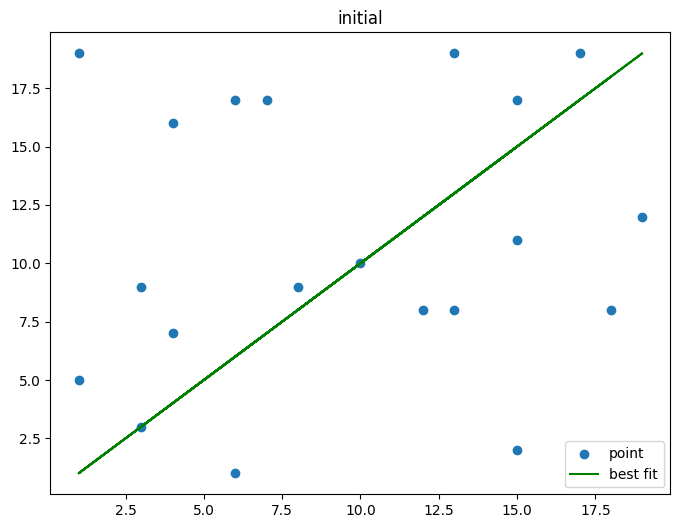

In [105]:
generate_best_line_plot(X,Y,1*X+0,"initial")

In [106]:
from sklearn.model_selection import train_test_split


X_train,X_test,Y_train,Y_test = train_test_split(X,Y,train_size=0.6)

In [107]:
class SimpleLinearRegression:

    def __init__(self, max_iter , lr, tolerance, patience):

        self.max_iter = int(max_iter)
        self.lr = lr
        self.tol = tolerance
        self.patience = patience


    def fit(self,X,Y):

        m,c = 1,0
        n = X.shape[0]

        count = 0
        last_mse = 0

        for i in tqdm(range(self.max_iter)):

            y_pred = m*X + c
    
            dm = -2 * np.sum((Y - y_pred)*X)/n
            dc = -2 * np.sum(Y - y_pred)/n
    
            m -= self.lr*dm
            c -= self.lr*dc
            # print(dm,dc,m,c)
    
            mse =  np.sum(np.square ( y_pred - Y))/n
            
            if mse < self.tol:
                print(f"Converged at {i}")
                break

            if mse == last_mse:
                count+=1

            if count > self.patience:
                print(f"Patience reached at {i}")
                break
                
            if i%10000==0:
                # generate_best_line_plot(X,Y,m,c,f"iteration {i}")
                print(f"Iteration [{i}/{self.max_iter}] Loss : {mse}")

            last_mse = mse
        return m,c
    
    @staticmethod
    def predict(X,m,c):
        
        return m*X + c
    

In [108]:
custom_lr_model = SimpleLinearRegression(max_iter=2e5,lr=1e-4,tolerance=0, patience = 5)
coeff,intercept = custom_lr_model.fit(X_train,Y_train)

  0%|          | 0/200000 [00:00<?, ?it/s]

Iteration [0/200000] Loss : 50.666666666666664
Iteration [10000/200000] Loss : 39.24716665948903
Iteration [20000/200000] Loss : 35.63763486518031
Iteration [30000/200000] Loss : 34.41454413108105
Iteration [40000/200000] Loss : 34.00009953574648
Iteration [50000/200000] Loss : 33.85966488293348
Iteration [60000/200000] Loss : 33.812078566372186
Iteration [70000/200000] Loss : 33.7959539313301
Iteration [80000/200000] Loss : 33.79049009478991
Iteration [90000/200000] Loss : 33.78863867243772
Iteration [100000/200000] Loss : 33.78801131751944
Iteration [110000/200000] Loss : 33.78779873815145
Iteration [120000/200000] Loss : 33.787726705580454
Iteration [130000/200000] Loss : 33.78770229732609
Iteration [140000/200000] Loss : 33.78769402658312
Iteration [150000/200000] Loss : 33.78769122403984
Iteration [160000/200000] Loss : 33.787690274397356
Iteration [170000/200000] Loss : 33.78768995261076
Iteration [180000/200000] Loss : 33.787689843573304
Iteration [190000/200000] Loss : 33.78768

train_mse 33.787689794106306
test_mse 35.15733688675028


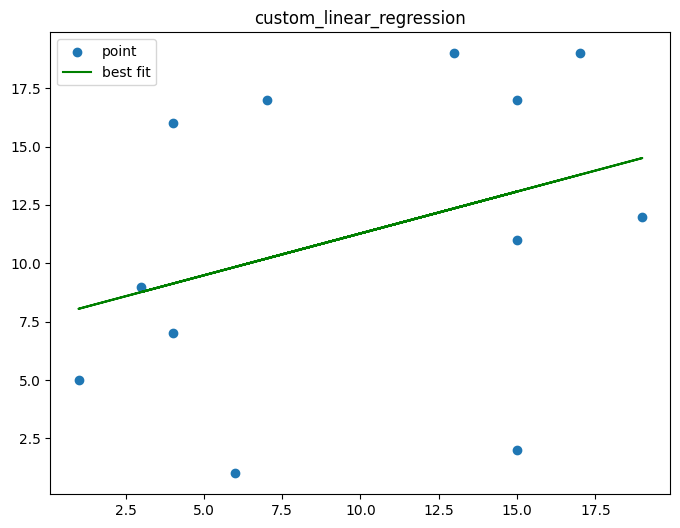

In [109]:
ypred = SimpleLinearRegression.predict(X_test.reshape(-1,1),coeff,intercept)
ypred2 = SimpleLinearRegression.predict(X_train.reshape(-1,1),coeff,intercept)

print('train_mse',mean_squared_error(y_pred=ypred2,y_true=Y_train))
print('test_mse',mean_squared_error(y_pred=ypred,y_true=Y_test))

generate_best_line_plot(X_train,Y_train,ypred2,'custom_linear_regression')

## Sklearn Linear Regression

train_mse 33.78768978768979
test_mse 35.15695290026702


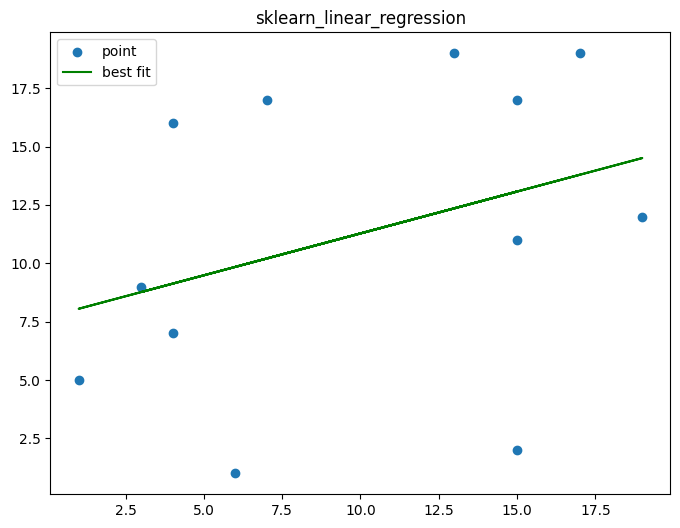

In [110]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train.reshape(-1,1),Y_train)

ypred = model.predict(X_test.reshape(-1,1))
ypred2 = model.predict(X_train.reshape(-1,1))

print('train_mse',mean_squared_error(y_pred=ypred2,y_true=Y_train))
print('test_mse',mean_squared_error(y_pred=ypred,y_true=Y_test))

generate_best_line_plot(X_train,Y_train,ypred2,'sklearn_linear_regression')